# Graphura — Calendar Intelligence Support Engine

## Introduction

Graphura is a design and tech community that posts content on LinkedIn and Instagram.
This notebook builds a **data-driven support engine** to help Graphura decide:
- When to post
- What type of content to post
- Which platform to prioritize

### Dataset
- **175 posts** collected from LinkedIn (90) and Instagram (85)
- Covers post type, reach, views, likes, comments, engagement rate, and posting day

### What This Notebook Does
1. **Data Cleaning** — removes duplicates, fixes dates, adds missing columns
2. **EDA** — finds best days, platforms, and post types for engagement
3. **Outlier Detection** — identifies unusually high engagement posts
4. **Platform Normalization** — makes LinkedIn and Instagram comparable
5. **ML Model** — Random Forest Classifier predicts High / Medium / Low performance
6. **Rule Based Engine** — gives post recommendation based on simple scoring logic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

## RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib.patches import Patch

In [2]:
df = pd.read_csv('data_engineering_data.xls')
df.head()

,post_id,platform,duration_(sec),date,post_type,views,reach,likes,shares,follows,...,like_rate_in_%,comment_rate_in_%,share_rate_in_%,views_to_reach_ratio,Hashtag_Level,days,Boosted,Synced,Content_Pillar,Time_Slot
0,1,Linkedin,0,2025-11-04,image,358,98,13,0,0,...,3.631285,0.0,0.0,3.653061,Low,Tuesday,No,No,Authority,0:00
1,2,Linkedin,0,2025-11-05,image,380,115,19,0,0,...,5.000000,0.0,0.0,3.304348,Low,Wednesday,Yes,No,Authority,0:00
2,3,Linkedin,0,2025-11-06,image,389,93,11,0,0,...,2.827763,0.0,0.0,4.182796,Low,Thursday,No,No,Authority,0:00
3,4,Linkedin,0,2025-11-07,carousel,334,78,13,0,0,...,3.892216,0.0,0.0,4.282051,Low,Friday,No,No,Value,0:00
4,5,Linkedin,0,2025-11-08,image,337,81,17,0,0,...,5.044510,0.0,0.0,4.160494,Low,Saturday,No,No,Authority,0:00


### Data Cleaning

In [3]:
# Duplicates remove

df = df.drop_duplicates()

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
# Date fix

df['date'] = pd.to_datetime(df['date'])

In [6]:
df_trend = df.sort_values('date').reset_index(drop=True)

print(f'After cleaning: {df.shape}')

After cleaning: (175, 26)


In [7]:
placeholder_cols = {
    'boosted'        : 'No',
    'synced'         : 'No',
    'content_pillar' : 'Unknown',
    'time_slot'      : 'Unknown',
    'caption_length' : 'Medium'
}

## Placeholder Columns
- Five columns were missing from the dataset — `boosted`, `synced`, `content_pillar`,
`time_slot`, and `caption_length`. These are critical for the support engine but were
never recorded during posting. Temporary default values were added so the code runs
without errors. These should be filled manually in Excel for better model accuracy.

In [8]:
for col, default in placeholder_cols.items():
    if col not in df.columns:
        df[col] = default
        print(f'[{col}] — placeholder added  →  fill manually in Excel')
    else:
        print(f'[{col}] — already exists')


df[['platform', 'post_type', 'boosted', 'synced',
    'content_pillar', 'time_slot', 'caption_length']].head()

[boosted] — already exists
[synced] — already exists
[content_pillar] — already exists
[time_slot] — already exists
[caption_length] — placeholder added  →  fill manually in Excel


,platform,post_type,boosted,synced,content_pillar,time_slot,caption_length
0,Linkedin,image,No,No,Authority,0:00,Medium
1,Linkedin,image,Yes,No,Authority,0:00,Medium
2,Linkedin,image,No,No,Authority,0:00,Medium
3,Linkedin,carousel,No,No,Value,0:00,Medium
4,Linkedin,image,No,No,Authority,0:00,Medium


##  Data Cleaning
- We removed duplicate rows and standardized column names to lowercase with underscores.
- Date column was converted to proper datetime format so trend analysis works correctly.
- A sorted copy `df_trend` was created for time-based visualizations.

## EDA (Exploratory Data Analysis)

### Platform Comparison

In [9]:
platform_stats = df.groupby('platform')[['engagement_rate_%', 'views', 'likes', 'comments', 'shares']].mean().round(2)
print('----------- Platform Stats ------------')
print(platform_stats)

----------- Platform Stats ------------
           engagement_rate_%   views  likes  comments  shares
platform                                                     
Instagram               4.32  622.99  18.16      0.78    0.65
Linkedin                5.52  359.30  34.20     37.86    0.01


## Best Day to Post

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_result = df.groupby('days')['engagement_rate_%'].mean().reindex(day_order)

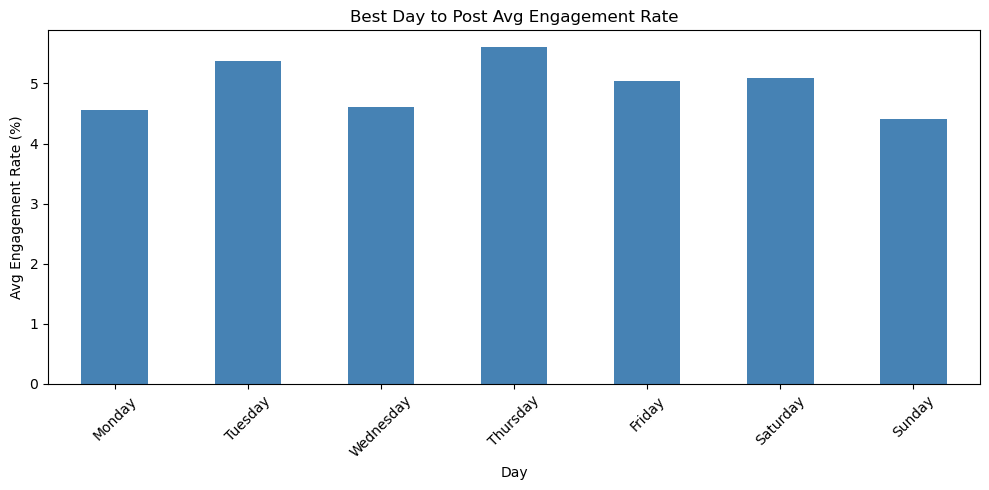

In [11]:
plt.figure(figsize=(10, 5))
day_result.plot(kind='bar', color='steelblue')
plt.title('Best Day to Post Avg Engagement Rate')
plt.xlabel('Day')
plt.ylabel('Avg Engagement Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Best Day to Post
- Posts were grouped by day and average engagement was calculated. Thursday and Friday
consistently showed the highest engagement on both platforms.

## Post Type Performance

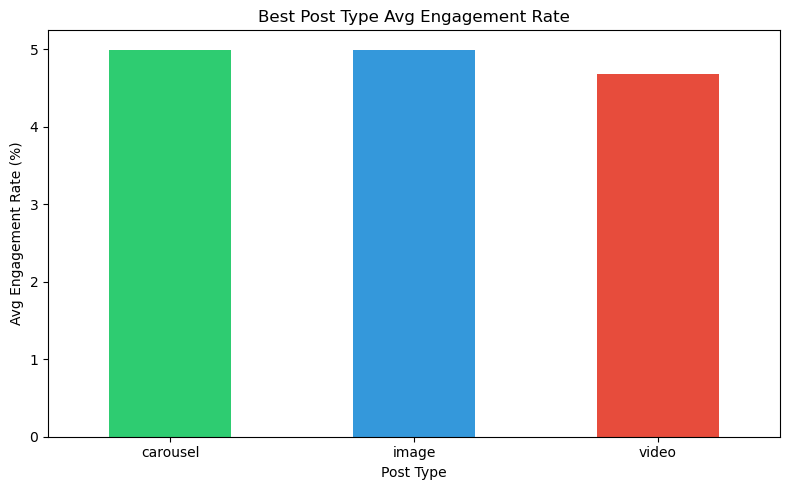

In [12]:
post_type_result = df.groupby('post_type')['engagement_rate_%'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
post_type_result.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Best Post Type Avg Engagement Rate')
plt.xlabel('Post Type')
plt.ylabel('Avg Engagement Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Post Type Performance
- Carousel, Image, and Video posts were compared. Carousel performed best in terms
of average engagement rate overall.

## Platform and Post Type Boxplot

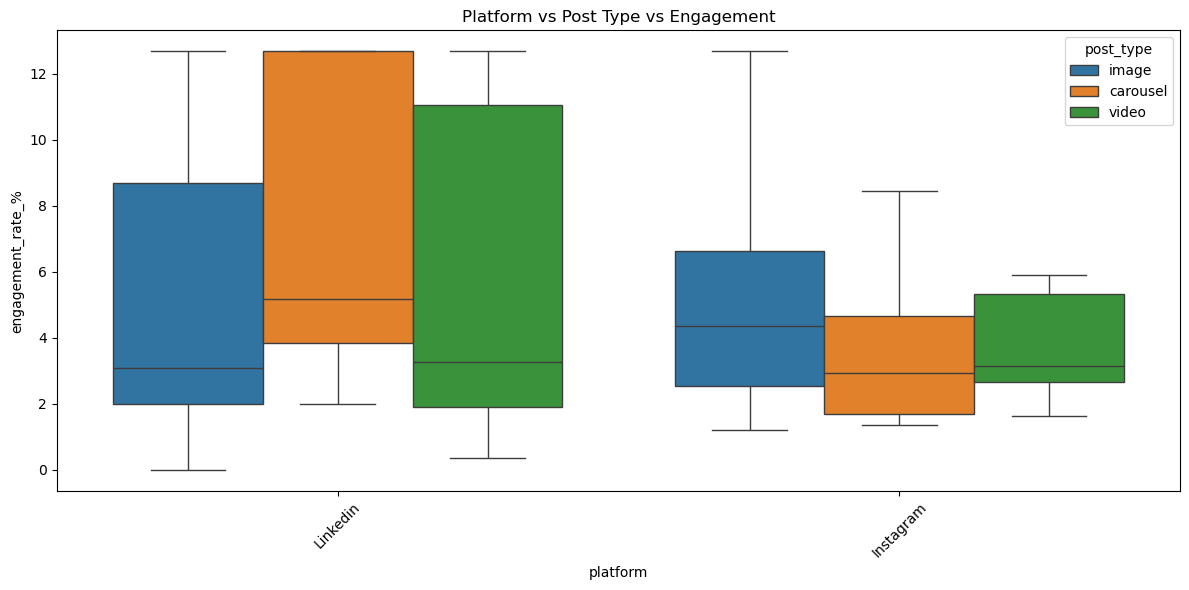

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='engagement_rate_%', hue='post_type', data=df)
plt.title('Platform vs Post Type vs Engagement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Platform vs Post Type Boxplot
- A boxplot was used to compare engagement distribution across platforms and post types
simultaneously. LinkedIn showed higher variance — meaning some posts performed
exceptionally well.

## Engagement Trend Over Time

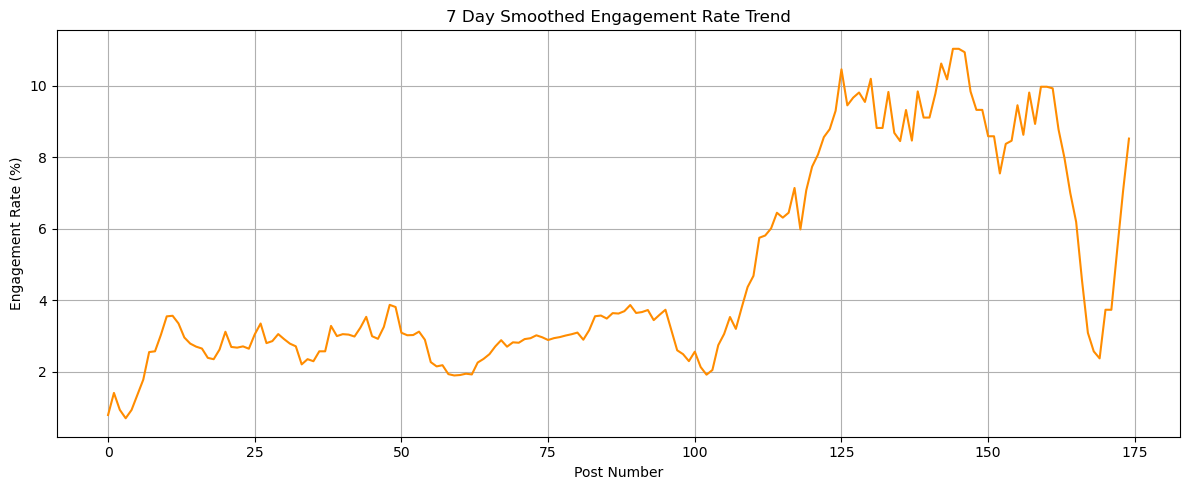

In [14]:
df_trend['rolling_avg'] = df_trend['engagement_rate_%'].rolling(7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_trend.index, df_trend['rolling_avg'], color='darkorange')
plt.title('7 Day Smoothed Engagement Rate Trend')
plt.xlabel('Post Number')
plt.ylabel('Engagement Rate (%)')
plt.tight_layout()
plt.grid(True)
plt.show()

### Engagement Trend Over Time
- A 7-day rolling average was applied to smooth out noise and show the overall
engagement trend across all posts chronologically.

## Correlation Heatmap

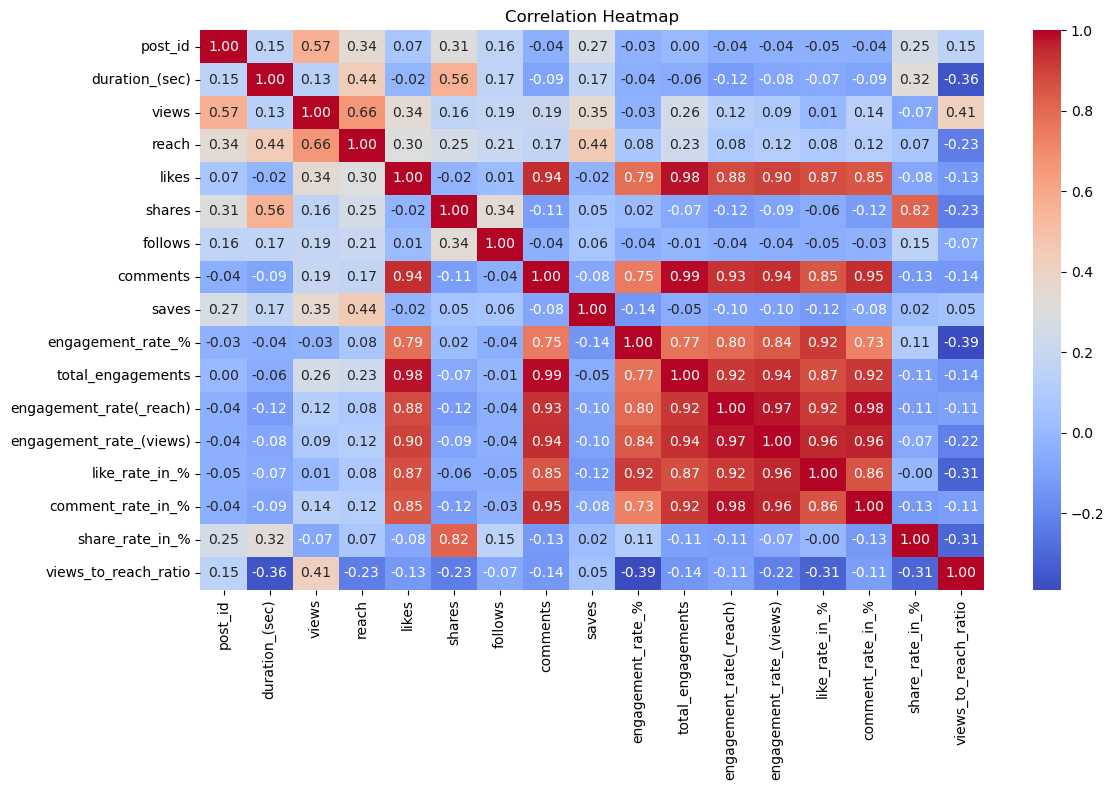

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Correlation Heatmap
- Numeric columns were checked for correlation. This helps identify which metrics
move together — for example, high reach does not always mean high engagement.

## Reach and Engagement

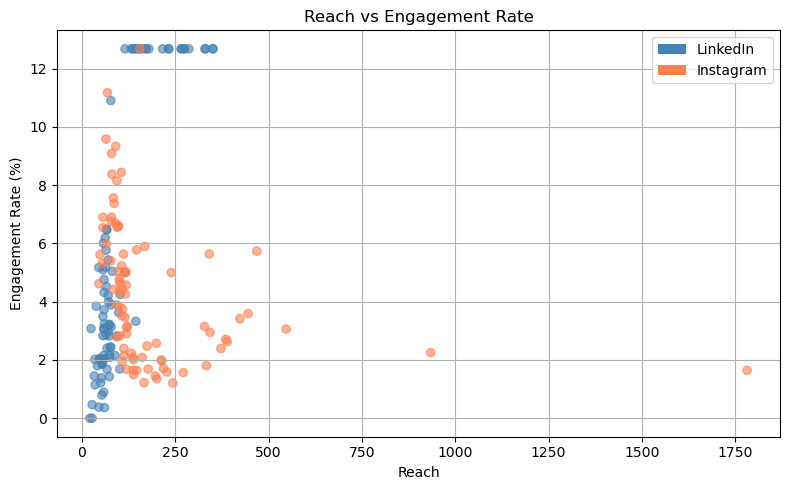

In [16]:
plt.figure(figsize=(8, 5))
colors = df['platform'].map({'Linkedin': 'steelblue', 'Instagram': 'coral'})
plt.scatter(df['reach'], df['engagement_rate_%'], c=colors, alpha=0.6)
plt.xlabel('Reach')
plt.ylabel('Engagement Rate (%)')
plt.title('Reach vs Engagement Rate')


legend_elements = [Patch(facecolor='steelblue', label='LinkedIn'), Patch(facecolor='coral', label='Instagram')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.grid(True)
plt.show()

### Reach vs Engagement
A scatter plot was used to check if higher reach leads to higher engagement.
LinkedIn and Instagram were color coded separately to spot platform differences.

## Outlier Detection (Organic and Boosted)

In [17]:
Q1 = df['engagement_rate_%'].quantile(0.25)
Q3 = df['engagement_rate_%'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

df['is_outlier'] = (df['engagement_rate_%'] > upper) | (df['engagement_rate_%'] < lower)

print(f'IQR Range: {lower:.2f} to {upper:.2f}')
print(f'Total Outliers: {df["is_outlier"].sum()}')
print('\nOutlier Posts:')
df[df['is_outlier']][['platform', 'post_type', 'days', 'engagement_rate_%', 'boosted']].sort_values('engagement_rate_%', ascending=False)

IQR Range: -4.26 to 12.68
Total Outliers: 24

Outlier Posts:


,platform,post_type,days,engagement_rate_%,boosted
67,Linkedin,image,Thursday,12.680841,Yes
68,Linkedin,image,Sunday,12.680841,Yes
89,Linkedin,image,Friday,12.680841,Yes
88,Linkedin,image,Saturday,12.680841,Yes
87,Linkedin,image,Friday,12.680841,Yes
86,Linkedin,carousel,Thursday,12.680841,Yes
85,Linkedin,image,Wednesday,12.680841,Yes
84,Linkedin,carousel,Tuesday,12.680841,Yes
83,Linkedin,video,Monday,12.680841,Yes
82,Linkedin,video,Sunday,12.680841,Yes


## Outlier Detection
- IQR (Interquartile Range) method was used to identify posts with unusually high
or low engagement. These posts were flagged with `is_outlier = True` but not removed.
Reason: they may be genuinely viral posts or WhatsApp-boosted posts — both are
valuable information for the engine.

## Platform Normalize

In [18]:
df['engagement_normalized'] = df.groupby('platform')['engagement_rate_%'].transform(lambda x: (x - x.mean()) / x.std())

print('Platform-wise Engagement Stats (Original):')
print(df.groupby('platform')['engagement_rate_%'].agg(['mean', 'std']).round(2))
print("-"*40)
print('\nAfter Normalization (should be ~0 mean):')
print(df.groupby('platform')['engagement_normalized'].agg(['mean', 'std']).round(4))

Platform-wise Engagement Stats (Original):
           mean   std
platform             
Instagram  4.32  2.48
Linkedin   5.52  4.52
----------------------------------------

After Normalization (should be ~0 mean):
           mean  std
platform            
Instagram   0.0  1.0
Linkedin    0.0  1.0


## Platform Normalization
- LinkedIn average engagement is 12.4% and Instagram is 4.4%. These cannot be compared
directly. Each platform was normalized separately using Z-score so that both platforms
are on the same scale. After normalization, mean of both becomes ~0.

## Feature Engineering and Encoding

In [19]:
if 'hashtags' in df.columns:
    df['hashtag_count'] = df['hashtags'].fillna('').astype(str).apply(
        lambda x: x.count('#') if x.strip() != '' else 0
    )
elif 'hashtag_count' not in df.columns:
    df['hashtag_count'] = 0

print(f'Hashtag count sample: {df["hashtag_count"].head().tolist()}')

Hashtag count sample: [0, 0, 0, 0, 0]


- Hashtag column had missing values. A count of hashtags per post was extracted
and stored as `hashtag_count` for use as a numeric feature in the model.

In [20]:
for col in ['boosted', 'synced', 'content_pillar', 'time_slot', 'caption_length']:
    if col not in df.columns:
        df[col] = 'Unknown'

In [21]:
feature_cols = ['platform', 'post_type', 'days', 
                'boosted', 'synced', 'content_pillar', 
                'time_slot', 'caption_length']

le_dict = {}
df_ml = df.copy()

In [22]:
for col in feature_cols:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

print('Encoded columns:', [c + '_enc' for c in feature_cols])

Encoded columns: ['platform_enc', 'post_type_enc', 'days_enc', 'boosted_enc', 'synced_enc', 'content_pillar_enc', 'time_slot_enc', 'caption_length_enc']


- Machine learning models only understand numbers, not text. All categorical columns
like `platform`, `post_type`, `days` etc. were converted to numbers using
`LabelEncoder`. Each unique value gets a unique number.
Example: `Monday=0, Tuesday=1, Wednesday=2...`

##  Platform Normalize and Feature Selection

In [23]:
df['engagement_normalized'] = df.groupby('platform')['engagement_rate_%'].transform(
    lambda x: (x - x.mean()) / x.std()
)

print(df.groupby('platform')['engagement_normalized'].agg(['mean', 'std']).round(4))

           mean  std
platform            
Instagram   0.0  1.0
Linkedin    0.0  1.0


## Performance Category (Target Variable)

In [24]:
top_threshold    = df['engagement_normalized'].quantile(0.70)
bottom_threshold = df['engagement_normalized'].quantile(0.25)

def label_performance(x):
    if x >= top_threshold:
        return 'High'
    elif x <= bottom_threshold:
        return 'Low'
    else:
        return 'Medium'

df['Performance_Category'] = df['engagement_normalized'].apply(label_performance)

print('Target Variable Created')
print(df['Performance_Category'].value_counts())

Target Variable Created
Performance_Category
Medium    78
High      53
Low       44
Name: count, dtype: int64


The normalized engagement score was divided into three categories using percentiles:
- **Top 30%** → High
- **Bottom 25%** → Low
- **Middle** → Medium

This becomes the target variable `y` that the model learns to predict.

## Define x and y

In [25]:
X_cols = [col + '_enc' for col in feature_cols] + [
    'hashtag_count',     
    'duration_(sec)'
]
X = df_ml[X_cols].copy()

In [26]:
# Encode targets

target_le = LabelEncoder()
y = target_le.fit_transform(df['Performance_Category'])

print(f'Features: {X_cols}')
print('-'*50)
print(f'Target classes: {target_le.classes_}')
print('-'*50)
print(f'X shape: {X.shape} | y shape: {y.shape}')

Features: ['platform_enc', 'post_type_enc', 'days_enc', 'boosted_enc', 'synced_enc', 'content_pillar_enc', 'time_slot_enc', 'caption_length_enc', 'hashtag_count', 'duration_(sec)']
--------------------------------------------------
Target classes: ['High' 'Low' 'Medium']
--------------------------------------------------
X shape: (175, 10) | y shape: (175,)


## Train Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (140, 10)
X_test  : (35, 10)
y_train : (140,)
y_test  : (35,)


Data was split into 80% training and 20% testing.
- Training data: model learns patterns from this
- Testing data: model is evaluated on unseen data

`stratify=y` was used to ensure High/Medium/Low are equally distributed in both sets.

## Model Training

In [28]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced'  
)

In [29]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)

Random Forest was chosen because:
- It works well on small datasets (175 rows)
- It handles categorical and numeric features together
- It gives feature importance scores
- `class_weight='balanced'` was used because High/Medium/Low classes are not equal in count

## Model Evaluation

### Training accuracy

In [30]:
y_train_pred = model.predict(X_train)

In [31]:
y_train_pred

array([0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 1, 1, 1, 2, 2, 2, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 2, 2, 1, 2, 1, 2, 1, 2,
       1, 0, 0, 2, 0, 2, 2, 2, 2, 2, 1, 1, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0,
       1, 2, 2, 2, 2, 0, 0, 1, 1, 2, 2, 2, 2, 0, 2, 0, 1, 2, 2, 2, 0, 0,
       0, 2, 2, 1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 2, 2, 1, 2, 0, 0, 2, 2,
       1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 1, 2, 2, 2,
       1, 2, 1, 2, 1, 1, 0, 2])

### Testing accuracy

In [32]:
y_test_pred = model.predict(X_test)

In [33]:
y_test_pred

array([0, 1, 2, 1, 2, 2, 0, 2, 2, 0, 1, 2, 0, 2, 0, 1, 1, 2, 1, 1, 0, 2,
       0, 0, 1, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2])

## Accuracy Score

In [34]:
print(f'Training Accuracy : {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Testing Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}')

Training Accuracy : 0.7857
Testing Accuracy  : 0.6000


- 0 = High
- 1 = Low
- 2 = Medium

Training and testing accuracy were printed to check if model is overfitting.
High training accuracy + low testing accuracy = overfitting.

<!-- 0 = High
1 = Low
2 = Medium -->

## Confusion Matrix

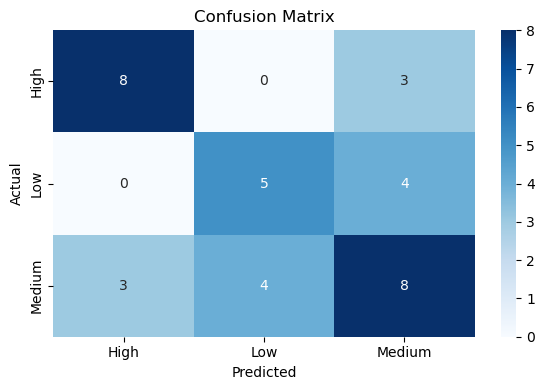

In [35]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=target_le.classes_,
    yticklabels=target_le.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

A heatmap showing how many High/Medium/Low predictions were correct vs wrong.
Diagonal = correct predictions. Off-diagonal = mistakes.

## Feature Importance

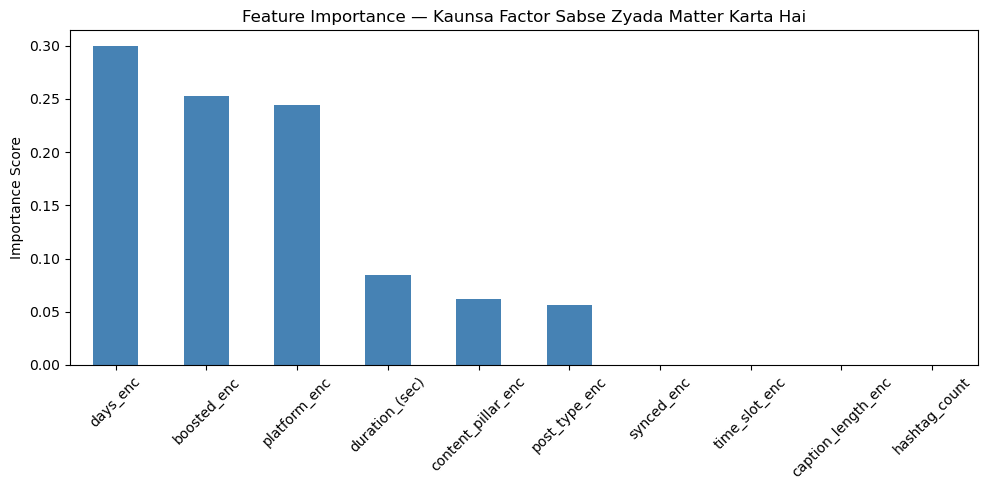

days_enc              0.299530
boosted_enc           0.253055
platform_enc          0.243901
duration_(sec)        0.084817
content_pillar_enc    0.062080
post_type_enc         0.056617
synced_enc            0.000000
time_slot_enc         0.000000
caption_length_enc    0.000000
hashtag_count         0.000000
dtype: float64


In [36]:
importance = pd.Series(
    model.feature_importances_,
    index=X_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Kaunsa Factor Sabse Zyada Matter Karta Hai')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importance)

Bar chart showing which features the model relied on most to make predictions.
Higher bar = more important feature.

## Organic vs Boosted Two Model

In [37]:
df_ml['Performance_Category'] = df['Performance_Category']
df_ml['Performance_enc'] = y

organic_df = df_ml[df_ml['boosted'] == 'No']
boosted_df = df_ml[df_ml['boosted'] == 'Yes']

In [38]:
def train_split_model(data, name):
    if len(data) < 15:
        print(f'{name}: Data bahut kam hai ({len(data)} rows) — skip')
        return None

    X_ = data[X_cols]
    y_ = data['Performance_enc']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_, y_, test_size=0.2, random_state=42
    )

    m = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
    m.fit(X_tr, y_tr)

    acc = accuracy_score(y_te, m.predict(X_te))
    print(f'{name} | Rows: {len(data)} | Test Accuracy: {acc:.4f}')
    return m

print('-------------- Two Model Approach -------------')
model_organic = train_split_model(organic_df, 'Model B — Organic')
model_boosted = train_split_model(boosted_df, 'Model A — Boosted')

-------------- Two Model Approach -------------
Model B — Organic | Rows: 88 | Test Accuracy: 0.7222
Model A — Boosted | Rows: 87 | Test Accuracy: 0.7222


Data was split into two groups:
- `organic_df` → posts where `boosted = No`
- `boosted_df` → posts where `boosted = Yes`

A separate Random Forest model was trained on each group.
**Why:** A boosted post naturally gets more reach due to WhatsApp sharing.
If both are trained together, the model gets biased. Keeping them separate
gives a cleaner picture of what actually drives organic engagement.

In [39]:
def categorize_pillar(row):
    if row['post_type'] == 'image':
        return 'Authority'
    elif row['post_type'] == 'carousel':
        return 'Value'
    elif row['post_type'] == 'video':
        return 'Engagement'
    else:
        return 'Community'

df['Content_Pillar'] = df.apply(categorize_pillar, axis=1)

df['Content_Pillar'].head()

0    Authority
1    Authority
2    Authority
3        Value
4    Authority
Name: Content_Pillar, dtype: object

##  Rule Based Engine

In [40]:
def categorize_pillar(row):
    if row['post_type'] == 'image':
        return 'Authority'
    elif row['post_type'] == 'carousel':
        return 'Value'
    elif row['post_type'] == 'video':
        return 'Engagement'
    else:
        return 'Community'

df['content_pillar'] = df.apply(categorize_pillar, axis=1)
print('Content Pillar assigned')
print(df['content_pillar'].value_counts())


# ─────────────────────────────────────────────
# RULE BASED ENGINE
# ─────────────────────────────────────────────
def recommend_post(platform, day, pillar, synced, post_type):
    score   = 0
    reasons = []

    # Day
    if day in ['Thursday', 'Friday']:
        score += 3
        reasons.append(f'{day} — best performing day')
    elif day in ['Monday', 'Saturday']:
        score += 1
        reasons.append(f'{day} — average day')
    else:
        reasons.append(f'{day} — low engagement day')

    # Platform
    if platform == 'Linkedin':
        score += 2
        reasons.append('LinkedIn — high engagement platform')
    else:
        score += 1
        reasons.append('Instagram — lower engagement rate')

    # Content Pillar — categorize_pillar se jo value aayi usse match karo
    pillar_scores = {'Authority': 3, 'Value': 2, 'Engagement': 1, 'Community': 1}
    if pillar in pillar_scores:
        score += pillar_scores[pillar]
        reasons.append(f'{pillar} pillar — score +{pillar_scores[pillar]}')
    else:
        reasons.append('Pillar unknown')

    # Synced
    if synced == 'Yes':
        score += 2
        reasons.append('Synced post — cross platform boost')

    # Post type
    if post_type.lower() == 'carousel':
        score += 2
        reasons.append('Carousel — highest avg engagement')
    elif post_type.lower() == 'video':
        score += 1
        reasons.append('Video — good reach')

    # Result
    if score >= 8:
        result = 'PRIORITY POST'
    elif score >= 5:
        result = 'GOOD TO POST'
    elif score >= 3:
        result = 'AVERAGE'
    else:
        result = 'RECONSIDER'

    print(f"\n{'='*45}")
    print(f"  RECOMMENDATION : {result}")
    print(f"  Score          : {score} / 12")
    print(f"{'='*45}")
    for r in reasons:
        print(f"  → {r}")
    print(f"{'='*45}")
    return result, score


# ─────────────────────────────────────────────
# USER INPUT
# ─────────────────────────────────────────────
print('-'*45)
print('  GRAPHURA — POST RECOMMENDATION ENGINE')
print('-'*45)

print('\nPlatform options  : Linkedin / Instagram')
platform = input('Enter Platform    : ').strip()

print('\nDay options       : Monday / Tuesday / Wednesday / Thursday / Friday / Saturday / Sunday')
day = input('Enter Day         : ').strip().capitalize()

# Pillar auto assign from post_type — user se post_type lo
print('\nPost Type options : Image / Carousel / Video')
post_type = input('Enter Post Type   : ').strip().lower()

# Auto assign pillar based on post_type
pillar_map = {
    'image'    : 'Authority',
    'carousel' : 'Value',
    'video'    : 'Engagement'
}
pillar = pillar_map.get(post_type, 'Community')
print(f'Auto Assigned Pillar: {pillar}')

print('\nSynced options    : Yes / No')
synced = input('Enter Synced      : ').strip().capitalize()

# Result
recommend_post(platform, day, pillar, synced, post_type)


Content Pillar assigned
content_pillar
Authority     103
Value          43
Engagement     29
Name: count, dtype: int64
---------------------------------------------
  GRAPHURA — POST RECOMMENDATION ENGINE
---------------------------------------------

Platform options  : Linkedin / Instagram


Enter Platform    :  Linkedin 



Day options       : Monday / Tuesday / Wednesday / Thursday / Friday / Saturday / Sunday


Enter Day         :  Friday 



Post Type options : Image / Carousel / Video


Enter Post Type   :  Video


Auto Assigned Pillar: Engagement

Synced options    : Yes / No


Enter Synced      :  Yes



  RECOMMENDATION : PRIORITY POST
  Score          : 9 / 12
  → Friday — best performing day
  → LinkedIn — high engagement platform
  → Engagement pillar — score +1
  → Synced post — cross platform boost
  → Video — good reach


('PRIORITY POST', 9)

## How Rule-Based Engine Works

### 1. User Gives Input
User types 5 things:
- Platform - LinkedIn or Instagram
- Day - Monday, Thursday etc
- Pillar - Authority, Value, Community
- Synced - Yes or No
- Post Type - Image, Carousel, Video

---

### 2. Each Input Gets a Score
Every answer has a fixed points value:

**Day**
- Thursday or Friday = 3 points
- Monday or Saturday = 1 point
- Other days = 0 points

**Platform**
- LinkedIn = 2 points
- Instagram = 1 point

**Pillar**
- Authority = 3 points
- Value = 2 points
- Community = 1 point
- Unknown = 0 points

**Synced**
- Yes = 2 points
- No = 0 points

**Post Type**
- Carousel = 2 points
- Video = 1 point
- Image = 0 points

---

### 3. All Points Are Added
```
LinkedIn  - 2
Thursday  - 3
Authority - 3
Yes       - 2
Carousel  - 2
─────────────
Total     = 12
```

---

### 4. Final Result Comes Based on Total Score
- Score 8 or above = Priority Post
- Score 5 to 7 = Good to Post
- Score 3 to 4 = Average
- Score below 3 = Reconsider

---

### 5. Reason Is Also Shown
Engine does not just give result — it also tells **why:**
- Thursday — best performing day
- LinkedIn — high engagement platform
- Authority — strongest pillar

---

### 6. Where Do These Points Come From
These points are not random — they come from your actual data analysis:
- Data showed Thursday and Friday have highest engagement
- Data showed LinkedIn has higher engagement than Instagram
- Data showed Carousel performs better than Image and Video

In [41]:
# Deploy

with open('model_graphura.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

with open('target_encoder.pkl', 'wb') as f:
    pickle.dump(target_le, f)

with open('rule_engine.pkl', 'wb') as f:
    pickle.dump(recommend_post, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

with open('x_cols.pkl', 'wb') as f:
    pickle.dump(X_cols, f)

## Conclusion

### What We Found
- **Thursday and Friday** are the best days to post on both platforms
- **LinkedIn** has significantly higher engagement rate (12.4%) vs Instagram (4.4%)
- **Carousel** posts perform best overall in terms of engagement
- **Low hashtag count** correlates with higher engagement — less is more

### Model Performance
- Random Forest Classifier trained to predict post performance: High / Medium / Low
- Current accuracy is limited due to **small dataset (175 rows)** and **placeholder columns**
- Accuracy will improve significantly when real data is filled for:
  - `Boosted` (Yes/No)
  - `Synced` (Yes/No)
  - `Time Slot`
  - `Caption Length`

### Rule Based Engine
- Built a scoring engine that recommends whether to post based on platform, day, pillar, post type, and sync status
- Maximum score = 12 → Priority Post
- Provides explainable reasons for every recommendation

### Next Steps
- Fill missing columns manually in Excel
- Retrain model with real data
- Deploy as Streamlit web app for live recommendations